# 실습 2. Bagging과 Random Forest

## 데이터
- 데이터셋: `sklearn.datasets.load_breast_cancer()`
- 데이터 내용: 유방암 진단에 사용되는 종양의 반지름, 질감, 면적, 오목도 등 수치 feature
- target: 종양 진단 결과
  - `0`: malignant, 악성
  - `1`: benign, 양성

## 실습 목표
- bootstrap sampling과 OOB 샘플을 직접 확인
- 단일 결정트리와 BaggingClassifier 성능 비교
- RandomForestClassifier의 OOB score와 feature importance 확인
- RandomForestRegressor로 회귀 예측 흐름 확인


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_breast_cancer, load_diabetes
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import BaggingClassifier, RandomForestClassifier, RandomForestRegressor
from sklearn.metrics import classification_report, root_mean_squared_error, r2_score

cancer = load_breast_cancer(as_frame=True)
X = cancer.data
y = cancer.target

print('X:', X.shape)
print('y:', y.shape)
print('target names:', cancer.target_names)
display(X.head())


X: (569, 30)
y: (569,)
target names: ['malignant' 'benign']


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


## 문제 1. 학습/평가 데이터 분리

`train_test_split()`으로 학습 데이터와 평가 데이터를 분리하세요.

### 요구사항
- `test_size=0.2` 사용
- `random_state=42` 사용
- `stratify=y` 사용
- 분리 결과 shape 출력

### 힌트
- 분류 문제에서 클래스 비율을 유지하려면 `stratify=y`를 사용함.

### 실행 결과
```text
X_train: (455, 30)
X_test: (114, 30)
y_train: (455,)
y_test: (114,)
```


In [2]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print('X_train:', X_train.shape)
print('X_test:', X_test.shape)
print('y_train:', y_train.shape)
print('y_test:', y_test.shape)

X_train: (455, 30)
X_test: (114, 30)
y_train: (455,)
y_test: (114,)


## 문제 2. Bootstrap sampling과 OOB 샘플 확인

원본 인덱스 0~9에서 bootstrap sample을 만들고 OOB 인덱스를 확인하세요.

### 요구사항
- `np.random.seed(42)` 사용
- `np.random.choice()`에서 `replace=True` 사용
- 원본 인덱스, bootstrap 인덱스, OOB 인덱스, 중복 수 출력

### 힌트
- OOB는 bootstrap sample에 뽑히지 않은 원본 샘플임.

### 실행 결과
```text
원본 인덱스: [0 1 2 3 4 5 6 7 8 9]
bootstrap 인덱스: [6 3 7 4 6 9 2 6 7 4]
OOB 인덱스: [0 1 5 8]
중복된 샘플 수: 4
```


In [3]:
np.random.seed(42)  # 다시 실행해도 똑같은 숫자 나오도록 고정

original_indices = np.arange(10)    # 0부터 9까지 숫자가 존재하는 ndarray를 생성

# 부트스트랩 샘플링: 랜덤 뽑기 (중복 허용 == 복원 추출)
bootstrap_indices = np.random.choice(
    original_indices,
    size = len(original_indices),
    replace=True        # 복원 추출 (추출 후 다시 원래 데이터에서 중복 추출을 하기 위함)
)

print("원본:", original_indices)
print("부트스트랩 샘플링:", bootstrap_indices)

# setdiff1d: 차집합
oob_incies = np.setdiff1d(original_indices, bootstrap_indices)
print("OOB:", oob_incies)
print("중복된 샘플 수:", len(bootstrap_indices) - len(np.unique(bootstrap_indices)) )

원본: [0 1 2 3 4 5 6 7 8 9]
부트스트랩 샘플링: [6 3 7 4 6 9 2 6 7 4]
OOB: [0 1 5 8]
중복된 샘플 수: 4


## 문제 3. 단일 결정트리와 BaggingClassifier 비교

단일 결정트리와 BaggingClassifier를 같은 데이터로 학습하고 점수를 비교하세요.

### 요구사항
- 단일 결정트리: `DecisionTreeClassifier(random_state=42)`
- BaggingClassifier 기본 모델: `DecisionTreeClassifier(random_state=42)`
- `n_estimators=100`, `max_samples=0.8`, `bootstrap=True`, `oob_score=True`
- 모델명, 학습셋 accuracy, 평가셋 accuracy, OOB score를 표로 출력

### 해석 포인트
- 학습셋 점수만 보지 말고 평가셋 점수를 함께 봐야 함.
- OOB score는 Bagging에서 자체 검증 점수처럼 참고할 수 있음.

### 실행 결과
```text
model          train_accuracy  test_accuracy  oob_score
single_tree    1.000000        0.912281       NaN
bagging_tree   1.000000        0.947368       0.956044
```


In [11]:
bagging_clf = BaggingClassifier(    # baggingClassifier '모델 생성'.
    estimator=DecisionTreeClassifier(random_state=42),
    n_estimators=100,   # 생성할 모델 개수
    max_samples=0.8,    # 0.8는 전체 데이터의 80%를 의미 --> 데이터의 80% 크기 만큼 부트스트램 샘플링 수행
    bootstrap=True,     # 데이터 추출 후 다시 복원 --> 중복 데이터 추출 목적
    oob_score=True,      # 뽑히지 않은 샘플 데이터로 자체 테스트 수행, y의 개념.
    random_state=42,
    n_jobs=-1   # 병렬 처리 개수 (모델 동시에 몇 개 돌릴 건지)
)

# 배깅과 비교할 단일 결정 트리
single_tree_clf = DecisionTreeClassifier(random_state=42)

models_for_compare = {
    'single_tree': single_tree_clf,
    'bagging_tree': bagging_clf
}

bagging_compare_results = []
for name, model in models_for_compare.items():
    model.fit(X_train, y_train)

    # score(): 분류 모델에서는 기본적으로 accuracy를 반환함.
    # train_accuracy와 test_accuracy 차이가 크면 과대적합 가능성을 의심할 수 있음.
    bagging_compare_results.append({
        'model': name,
        'train_accuracy': model.score(X_train, y_train),
        'test_accuracy': model.score(X_test, y_test),

        # 단일 결정트리에는 oob_score_ 속성이 없음.
        # getattr(..., np.nan)을 사용해 속성이 없을 때는 NaN으로 표시함.
        'oob_score': getattr(model, 'oob_score_', np.nan)   # getattr: model 안에서 'oob_score_'를 가져오는 함수. 없으면 nan.
    })


bagging_compare_df = pd.DataFrame(bagging_compare_results)
display(bagging_compare_df)

,model,train_accuracy,test_accuracy,oob_score
0,single_tree,1.0,0.912281,NaN
1,bagging_tree,1.0,0.947368,0.956044


## 문제 4. RandomForestClassifier 학습과 feature importance 확인

RandomForestClassifier를 학습하고 성능과 feature importance를 확인하세요.

### 요구사항
- `n_estimators=200`, `max_depth=5`, `max_features='sqrt'`, `oob_score=True`
- 학습셋 accuracy, 평가셋 accuracy, OOB score 출력
- `classification_report()` 출력
- 상위 10개 feature importance를 표와 막대그래프로 출력

### 실행 결과
```text
학습셋 accuracy: 약 0.9934
평가셋 accuracy: 약 0.9561
OOB score: 약 0.9582
상위 feature 예: worst perimeter, worst area, worst concave points 등
```


학습셋 accuracy: 0.9934065934065934
평가셋 accuracy: 0.956140350877193
OOB score: 0.9626373626373627
              precision    recall  f1-score   support

   malignant       0.95      0.93      0.94        42
      benign       0.96      0.97      0.97        72

    accuracy                           0.96       114
   macro avg       0.96      0.95      0.95       114
weighted avg       0.96      0.96      0.96       114



,feature,importance
23,worst area,0.138294
27,worst concave points,0.132993
20,worst radius,0.100805
7,mean concave points,0.098489
22,worst perimeter,0.072224
2,mean perimeter,0.068612
0,mean radius,0.067465
6,mean concavity,0.057445
3,mean area,0.050615
26,worst concavity,0.031544


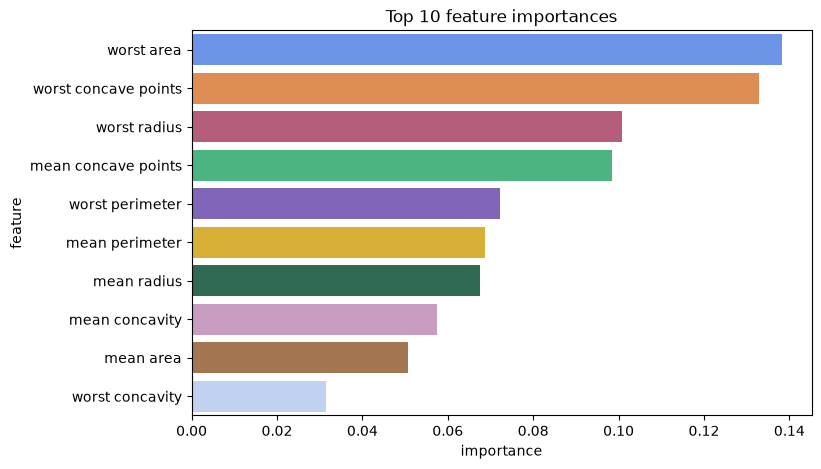

In [7]:
rf_clf = RandomForestClassifier(
    n_estimators=100,
    max_depth=5,
    max_features='sqrt',    # sqrt == 제곱근(루트)   전체 중 제곱근 된 수 만큼만 feature를 뽑음.
    oob_score=True,     # 부트스트랩 샘플링 시 뽑히지 않은 데이터로 자체 평가
    random_state=42,
    n_jobs=1
)

# 학습
rf_clf.fit(X_train, y_train)

# 예측
rf_y_pred = rf_clf.predict(X_test)

# 정확도(평가)
print("학습셋 accuracy:", rf_clf.score(X_train, y_train))
print("평가셋 accuracy:", rf_clf.score(X_test, y_test))
print("OOB score:", rf_clf.oob_score_)

print(classification_report(y_test, rf_y_pred, target_names=cancer.target_names))


# 학습셋, 평가셋 점수가 모두 높고 차이가 적으면 과대 적합이 발생하지 않음을 의미 == 안정적


feature_importance_df = pd.DataFrame({
    'feature': cancer.feature_names,
    'importance': rf_clf.feature_importances_
}).sort_values('importance', ascending=False)

# 중요도가 높은 상위 10개 feature만 표로 확인함.
display(feature_importance_df.head(10))

plt.figure(figsize=(8, 5))
sns.barplot(
    data=feature_importance_df.head(10),
    x='importance',
    y='feature',
    hue='feature',
    legend=False
)
plt.title('Top 10 feature importances')
plt.xlabel('importance')
plt.ylabel('feature')
plt.show()

## 문제 5. RandomForestRegressor 회귀 모델 학습

Diabetes 데이터로 RandomForestRegressor를 학습하고 회귀 지표를 확인하세요.

### 요구사항
- `load_diabetes(as_frame=True)` 사용
- `test_size=0.2`, `random_state=42`
- `RandomForestRegressor(n_estimators=300, max_depth=5, random_state=42, n_jobs=1)` 사용
- 평가셋 R2, RMSE 출력

### 실행 결과
```text
평가셋 R2: 약 0.4574
평가셋 RMSE: 약 53.6192
```


In [10]:
# as_frame=True를 사용해 feature 이름이 있는 DataFrame 형태로 데이터를 받음.
diabetes = load_diabetes(as_frame=True)

# reg_X: 건강 지표 feature 데이터
# reg_y: 1년 후 당뇨 진행 정도를 나타내는 target 값
reg_X = diabetes.data
reg_y = diabetes.target

reg_X_train, reg_X_test, reg_y_train, reg_y_test = train_test_split(
    reg_X,
    reg_y,
    test_size=0.2,
    random_state=42
)

print('회귀 feature shape:', reg_X.shape)
print('회귀 target shape:', reg_y.shape)
display(reg_X.head())


# RandomForestRegressor 생성
rf_reg = RandomForestRegressor(
    n_estimators=300,
    max_depth=5,
    random_state=42,
    n_jobs=1
)

# 학습
rf_reg.fit(reg_X_train, reg_y_train)

# 평가(R2, RMSE)
reg_pred = rf_reg.predict(reg_X_test)   # 예측

print("학습셋 R2:", rf_reg.score(reg_X_train, reg_y_train))
print("평가셋 R2:", rf_reg.score(reg_X_test, reg_y_test))
print("평가셋 RMSE:", root_mean_squared_error(reg_y_test, reg_pred))


# (참고) Diabetes 데이터 자체가 예측이 어려운 데이터 셋

# 학습셋 R2 >> 평가셋 R2 -> 과대적합 의심
# (학습셋이 지나치게 높을 때)

회귀 feature shape: (442, 10)
회귀 target shape: (442,)


,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6
0,0.038076,0.050680,0.061696,0.021872,-0.044223,-0.034821,-0.043401,-0.002592,0.019907,-0.017646
1,-0.001882,-0.044642,-0.051474,-0.026328,-0.008449,-0.019163,0.074412,-0.039493,-0.068332,-0.092204
2,0.085299,0.050680,0.044451,-0.005670,-0.045599,-0.034194,-0.032356,-0.002592,0.002861,-0.025930
3,-0.089063,-0.044642,-0.011595,-0.036656,0.012191,0.024991,-0.036038,0.034309,0.022688,-0.009362
4,0.005383,-0.044642,-0.036385,0.021872,0.003935,0.015596,0.008142,-0.002592,-0.031988,-0.046641


학습셋 R2: 0.7398126170636952
평가셋 R2: 0.4573543689863395
평가셋 RMSE: 53.61920270555988
